# Генеративные нейросети
## Задание 2

**Правила:**

* Дедлайны см. в боте. После дедлайна работы не принимаются кроме случаев наличия уважительной причины.
* Выполненную работу нужно отправить телеграм-боту. Для начала работы с ботом каждый раз отправляйте `/start`. Дождитесь подтверждения от бота, что он принял файл. Если подтверждения нет, то что-то не так. **Работы, присланные иным способом, не принимаются.**
* Дедлайны см. в боте. После дедлайна работы не принимаются кроме случаев наличия уважительной причины.
* Прислать нужно **ноутбук в формате `ipynb`**.
* Следите за размером файлов. **Бот не может принимать файлы весом более 20 Мб.** Если файл получается больше, заранее разделите его на несколько.
* Выполнять задание необходимо полностью самостоятельно. **При обнаружении списывания все участники списывания получат штраф.**
* Решения, размещенные на каких-либо интернет-ресурсах, не принимаются. Кроме того, публикация решения в открытом доступе может быть приравнена к предоставлении возможности списать.
* Для выполнения задания используйте этот ноутбук в качестве основы, **не исправляйте и не удаляйте условия!** Можно добавлять необходимое количество ячеек.
* Комментарии к решению пишите в markdown-ячейках.
* Выполнение задания (ход решения, выводы и пр.) должно быть осуществлено на русском языке.
* Решение проверяется системой ИИ-проверки <a href="https://thetahat.ru/"><img src="https://miptstats.github.io/theta_grader_small.png" style="display: inline; vertical-align: middle;"></a> **ThetaGrader**. Результат проверки валидируется и исправляется человеком, после чего комментарии отправляются студентам.
* Если код будет не понятен проверяющему, оценка может быть снижена.
* Никакой код из данного задания при проверке запускаться не будет. *Если код студента не выполнен, недописан и т.д., то он не оценивается.*
* В каждой задаче не забывайте делать **пояснения и выводы**.
* **Код из рассказанных на занятиях ноутбуков** можно использовать без ограничений.


**Правила оформления теоретических задач:**

* Решения необходимо прислать в виде $LaTeX$ в markdown-ячейках.
* В решениях поясняйте, чем вы пользуетесь, хотя бы кратко. Например, если пользуетесь независимостью, то достаточно подписи вида "*X и Y незав.*"
* Решение, в котором есть только ответ, и отсутствуют вычисления, оценивается в 0 баллов.



**Баллы за задание:**
* Задача 1 &mdash; 70 баллов.
* Задача 2 &mdash; 130 баллов.

-----------

In [1]:
# Bot check

# HW_ID: ds_gen2
# Бот проверит этот ID и предупредит, если случайно сдать что-то не то.

# Status: not final
# Перед отправкой в финальном решении удали "not" в строчке выше.
# Так бот проверит, что ты отправляешь финальную версию, а не промежуточную.
# Никакие значения в этой ячейке не влияют на факт сдачи работы.

In [2]:
import os
os.environ["OMP_NUM_THREADS"] = "20"
os.environ["MKL_NUM_THREADS"] = "20"
os.environ["NUMEXPR_NUM_THREADS"] = "20"
os.environ["OPENBLAS_NUM_THREADS"] = "20"
import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data
import torchvision
import torchvision.datasets as dset
import torchvision.transforms as transforms
import torchvision.utils as vutils
from torchsummary import summary
from torchmetrics.image.fid import FrechetInceptionDistance
from torchvision.models import inception_v3

from sklearn.datasets import make_blobs
from matplotlib.gridspec import GridSpec
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from torch.utils.data import TensorDataset, DataLoader
import math

from torch.autograd import Variable
from torchvision.datasets import ImageFolder
from torch.amp import autocast, GradScaler
from torch.utils.data import DataLoader, random_split, Dataset
from torchvision import datasets, transforms
from torchvision.utils import make_grid
from datetime import datetime
from IPython.display import clear_output
from tqdm.auto import tqdm
import torch.nn.functional as F


from torchmetrics.image.lpip import LearnedPerceptualImagePatchSimilarity


PATH = ""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import seaborn as sns
sns.set(palette='Set2')

from IPython.display import HTML
from IPython.display import clear_output

seed = 42
import random
random.seed(seed)
torch.manual_seed(seed);

import torch
torch.set_num_threads(20)

In [3]:
import seaborn as sns
sns.set(palette='Set2', font_scale=1.3)

device = torch.device("cuda:7" if torch.cuda.is_available() else "cpu")
USE_CUDA = torch.cuda.is_available()

### Ссылки на использование ИИ

Если при решении задач использовался ИИ, укажи здесь публичные ссылки на все чаты с ИИ и поясни, для каких целей он применялся. Обрати внимание на <a href="https://thetahat.ru/courses/ai-rules" target="_top">правила</a>.

**Задача 1**
1. ссылка
    - для чего использована
    - для чего использована
2. ссылка
    - для чего использована

**Задача 2**
1. ссылка
    - для чего использована
...

### Задача 1
Вам предстоит сравнить модели WGAN и WGAN-GP на практике и оценить их эффективность. Для этого вам предлагается провести эксперименты на картинках из MNIST и искусственном датасете из прошлого ДЗ.

**1.** Выпишите задачу оптимизации, которая решается в WGAN-GP.

Критик:
$$
E_{P}D(X) - E_{Q}D(G(Z)) - \lambda \left[E_{PI}(||\nabla D(x)|| - 1)^2 \right] \rightarrow \max_{D}
$$

$$
E_{Q}D(G(Z)) \rightarrow \max_{G}
$$

**2.** Реализуйте модель WGAN-GP и обучите её на датасете MNIST. В процессе обучения визуализируйте
* лоссы генератора и дискриминатора;
* средние значения дискриминатора для реальных, предсказанных изображений, и предсказанных изображений после дообучения, генератора;
* несколько примеров генераций генератора.

*Указания и рекомендации*
* Обязательно посмотрите код с занятий, например, семинар про WGAN.
* **Любой код с занятий можно использовать без ограничений.**
* Проведите достаточную настройку гиперпараметров: сложность нейросетей, количество итераций обучения, шаг обучения, оптимизатор.
* Начинайте работу с простых нейросетей на небольшом объеме данных, постепенно усложняйте процесс.
* Сохраняйте удачные запуски и обученные модели (пример в семинаре), чтобы при необходимости вернуться к ним.
* **Если у вас получаются плохие результаты, скорее всего модель обучилась неправильно, или гиперпараметры выбраны неудачно.** Перечитайте еще раз все рекомендации, перепроверьте свое решение. Если не помогло, задайте вопрос в чате.

In [4]:
batch_size = 256
z_dim = 30
n_channel = 1

In [5]:
def setup_data_loaders(batch_size=128, use_cuda=False):
    root = './data'
    download = True
    trans = transforms.ToTensor()

    train_set = dset.MNIST(
        root=root, train=True, transform=trans, download=download
    )

    kwargs = {'num_workers': 1, 'pin_memory': use_cuda}

    train_loader = torch.utils.data.DataLoader(
        dataset=train_set, batch_size=batch_size, shuffle=True, **kwargs
    )

    return train_loader

train_loader = setup_data_loaders(batch_size=batch_size, use_cuda=USE_CUDA)

In [6]:
class Reshape(nn.Module):
    def __init__(self, shape):
        super(Reshape, self).__init__()
        self.shape = shape

    def forward(self, x):
        return x.view(self.shape)

Запишем генератор и дискриминатор для WGAN-GP.

Нам надо для этого убрать BatchNorm.

In [7]:
class Generator(nn.Module):
    ''' Реализация модели сверточного генератора. '''

    def __init__(self, z_dim, n_channel, p=0.3):
        '''
        z_dim -- размерность скрытого пространства
        n_channel -- число каналов картинки
        p -- параметр dropout
        '''

        super(Generator, self).__init__()

        self.layers = nn.Sequential(

            nn.Linear(in_features=z_dim, out_features=7*7*64),
            nn.LeakyReLU(),
            nn.Dropout(p),
            Reshape((-1, 64, 7, 7)),  # Преобразуем вектор в картинку
            nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(num_features=64),
            nn.LeakyReLU(),
            nn.Dropout2d(p=p),
            nn.Upsample(size=(14, 14)),  # увеличиваем размер картинки
            nn.Dropout2d(p=p),
            nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(num_features=64),
            nn.LeakyReLU(),
            nn.Dropout2d(p=p),
            nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(num_features=64),
            nn.LeakyReLU(),
            nn.Dropout2d(p=p),
            nn.Conv2d(in_channels=64, out_channels=32, kernel_size=3, stride=1, padding=1),
            nn.Upsample(size=(28, 28)),  # увеличиваем размер картинки
            nn.LeakyReLU(),
            nn.Dropout2d(p=p),
            nn.Conv2d(in_channels=32, out_channels=n_channel, kernel_size=5, stride=1, padding=2),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.layers(x.squeeze())


class Discriminator(nn.Module):
    ''' Реализация модели сверточного дискриминатора. '''

    def __init__(self, n_channel, p=0.3):
        '''
        n_channel -- число каналов картинки
        p -- параметр dropout
        '''

        super(Discriminator, self).__init__()

        self.layers = nn.Sequential(
            nn.Conv2d(in_channels=n_channel, out_channels=256, kernel_size=5, stride=2, padding=1),
            # nn.BatchNorm2d(num_features=256),
            nn.LeakyReLU(),
            nn.Dropout2d(p=p),
            nn.Conv2d(in_channels=256, out_channels=128, kernel_size=3, stride=1, padding=1),
            # nn.BatchNorm2d(num_features=128),
            nn.LeakyReLU(),
            nn.Dropout2d(p=p),
            nn.Conv2d(in_channels=128, out_channels=64, kernel_size=3, stride=1, padding=1),
            # nn.BatchNorm2d(num_features=64),
            nn.LeakyReLU(),
            nn.Dropout2d(p=p),
            nn.MaxPool2d(kernel_size=2),
            nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, stride=1, padding=1),
            # nn.BatchNorm2d(num_features=64),
            nn.LeakyReLU(),
            nn.Flatten(),  # растягиваем тензор в вектор
            nn.Dropout(p=p),
            nn.Linear(in_features=2304, out_features=1),
        )

    def forward(self, x):
        return self.layers(x)

Уберем усечение весов -- его не должно быть при обучении дискриминатора.

Напишем функцию, для подсчета дополнительной потери из-за градиента.

In [8]:
def gradient_penalty(discriminator, real_data, fake_data):
    batch_size = real_data.size(0)

    if real_data.dim() == 4:
        epsilon = torch.rand(batch_size, 1, 1, 1, device=real_data.device)
    elif real_data.dim() == 2:
        epsilon = torch.rand(batch_size, 1, device=real_data.device)
    else:
        epsilon_shape = [batch_size] + [1] * (real_data.dim() - 1)
        epsilon = torch.rand(*epsilon_shape, device=real_data.device)
    
    epsilon = epsilon.expand_as(real_data)
    interpolated = epsilon * real_data + (1 - epsilon) * fake_data
    interpolated.requires_grad_(True)

    d_interpolated = discriminator(interpolated)

    grads = torch.autograd.grad(
        outputs=d_interpolated,
        inputs=interpolated,
        grad_outputs=torch.ones_like(d_interpolated),
        create_graph=True,
        retain_graph=True,
        only_inputs=True,
    )[0]

    grads = grads.view(batch_size, -1)
    grad_norm = grads.norm(2, dim=1)
    gp = ((grad_norm - 1) ** 2).mean()

    return gp

def train_discriminator(
    discriminator,
    optimizer,
    real_batch,
    fake_batch,
    lambda_gp=0.0,
    clip_value=0.01,  # клипаем, только если lambda_gp==0
    real_label=1,
    fake_label=-1,
):
    discriminator.zero_grad()
    discriminator.train(True)
    batch_size = real_batch.size(0)

    output_real = discriminator(real_batch).view(-1)
    output_fake = discriminator(fake_batch).view(-1)

    loss_WGAN = torch.mean(output_fake) - torch.mean(output_real)

    if lambda_gp > 0.0:
        gp = gradient_penalty(discriminator, real_batch, fake_batch)
        loss_D = loss_WGAN + lambda_gp * gp
    else:
        gp = torch.tensor(0.0, device=real_batch.device)
        loss_D = loss_WGAN

    loss_D.backward()
    optimizer.step()

    if lambda_gp == 0.0:
        for p in discriminator.parameters():
            p.data.clamp_(-clip_value, clip_value)

    mean_real = output_real.mean().item()
    mean_fake = output_fake.mean().item()

    return loss_D.item(), mean_real, mean_fake

def train_generator(
    generator, discriminator, optimizer, z_dim, batch_size, real_label=1
):
    """
    Функция, реализующая одну итерацию обучения генератора.
    generator -- PyTorch-модель генератора
    discriminator -- PyTorch-модель дискриминатора
    optimizer -- оптимизатор этой модели генератора
    criterion -- лосс
    z_dim -- размерность случайных векторов на входе генератора
    batch_size -- размер батча

    Возвращает:
    error -- значение лосса на данной итерации
    mean_fake -- среднее значение дискриминатора на сгенерированных объектах
    """

    discriminator.train(False)
    generator.zero_grad()

    # сгенерируем батч в латентном пространстве
    noise = torch.randn(batch_size, z_dim, device=device)
    label = torch.full(  # вектор из одинаковых меток real_label
        (batch_size,), real_label, dtype=torch.float, device=device
    )

    fake_batch = generator(noise)  # Получим объекты по сгенерированным векторам
    output = discriminator(fake_batch).view(-1)  # Прогоним их через дискриминатор
    loss_G = -torch.mean(output)
    loss_G.backward()
    mean_fake = output.mean().item()

    # Обновляем веса генератора
    optimizer.step()

    return loss_G.item(), mean_fake

In [9]:
def callback(
    losses_generator,
    losses_discriminator,
    D_real_means,
    D_fake_means,
    DG_fake_means,
    it
):
    '''
    Отрисовка текущего статуса обучения.
    losses_generator -- значение лосса генератора по итерациям
    losses_discriminator -- значение лосса дискриминатора по итерациям
    D_real_means -- среднее значение дискриминатора на реальных объектах по итерациям
    D_fake_means -- среднее значение дискриминатора на сгенерированных объектах по итерациям
    DG_fake_means -- среднее значение дискриминатора на сгенерированных объектах
                     по итерациям после обучения генератора
    it -- номер итерации
    '''

    # Отложенная очистка экрана
    clear_output(wait=True)

    # Объявление фигуры и сетки
    plt.figure(figsize=(16, 4), constrained_layout=False)
    plt.suptitle(f'Итерация {it}')
    plt.subplot(121)
    plt.plot(losses_generator, lw=2, label='генератор', alpha=0.7)
    plt.plot(losses_discriminator, lw=2, label='дискр.', alpha=0.7)
    plt.title('Лоссы (WGAN loss)')
    plt.legend()
    plt.xlabel('Номер итерации')
    plt.subplot(122)
    plt.plot(D_real_means, lw=2, label='реальные', alpha=0.7)
    plt.plot(D_fake_means, lw=2, label='сгенер.', alpha=0.7)
    plt.plot(DG_fake_means, lw=2, label='сгенер. после\nдообуч. генер.', alpha=0.7)
    plt.title('Среднее значение выхода дискриминатора')
    plt.ylabel('Скор дискриминатора')
    plt.xlabel('Номер итерации')
    plt.legend()
    plt.show()

In [10]:
generator = Generator(z_dim, n_channel, p=0.0).to(device)
discriminator = Discriminator(n_channel, p=0.0).to(device)

num_iter = 2001  # Количество итераций обучения
n_iter_generator = 1  # Количество итераций обучения генератора в одной общей итерации
n_iter_discriminator = 7  # Количество итераций обучения дискриминатора в одной общей итерации
callback_frequency = num_iter // 10  # Частота обновления графика
picture_save_frequency = 100  # Частота сохранения визуализации текущей генерации
lambda_gp = 10.0

lr = 0.0005  # learning rate

# Создадим фиксированный батч латентных векторов для визуализации
fixed_noise = torch.randn(batch_size, z_dim, device=device)

# Метки реальных и сгенерированных объектов
real_label = 1.
fake_label = -1.

# Оптимизаторы
optim_discriminator = optim.Adam(discriminator.parameters(), lr=lr)
optim_generator = optim.Adam(generator.parameters(), lr=lr)

In [11]:

def train_gan(
    generator,
    discriminator,
    train_loader,
    optim_generator,
    optim_discriminator,
    z_dim,
    device,
    num_iter=2001,
    n_iter_generator=1,
    n_iter_discriminator=7,
    callback_frequency=200,
    picture_save_frequency=100,
    lambda_gp=10.0,
    batch_size=64,
    callback=None,
    clip_value=0.01
):
    """
    Основной цикл обучения GAN/WGAN-GP.
    Возвращает:
        img_list               – список тензоров-сеток изображений
        losses_generator        – список значений лосса генератора
        losses_discriminator    – список значений лосса дискриминатора
        D_real_means, D_fake_means, DG_fake_means – списки средних значений выхода дискриминатора
    """

    img_list = []
    losses_generator = []
    losses_discriminator = []
    D_real_means, D_fake_means, DG_fake_means = [], [], []

    fixed_noise = torch.randn(batch_size, z_dim, device=device)

    data_iter = iter(train_loader)

    for it in range(num_iter):
        for _ in range(n_iter_discriminator):
            try:
                real_batch = next(data_iter)[0].to(device)
            except StopIteration:
                data_iter = iter(train_loader)
                real_batch = next(data_iter)[0].to(device)

            noise = torch.randn(real_batch.size(0), z_dim, device=device)
            fake_batch = generator(noise).detach()  # без градиента для G

            return_discr = train_discriminator(
                discriminator,
                optim_discriminator,
                real_batch,
                fake_batch,
                lambda_gp=lambda_gp,
                clip_value=clip_value
            )

        for _ in range(n_iter_generator):
            return_generator = train_generator(
                generator,
                discriminator,
                optim_generator,
                z_dim,
                batch_size
            )

        loss_G = return_generator[0]
        loss_D = return_discr[0]

        losses_generator.append(loss_G)
        losses_discriminator.append(loss_D)
        D_real_means.append(return_discr[1])
        D_fake_means.append(return_discr[2])
        DG_fake_means.append(return_generator[1])

        if callback and (it % callback_frequency == 0):
            callback(
                losses_generator,
                losses_discriminator,
                D_real_means,
                D_fake_means,
                DG_fake_means,
                it
            )

        if (it % picture_save_frequency == 0) or (it == num_iter - 1):
            with torch.no_grad():
                fake = generator(fixed_noise).detach().cpu()
            img_grid = vutils.make_grid(fake, nrow=16, padding=2, normalize=True)
            img_list.append(img_grid)

    return (
        img_list,
        losses_generator,
        losses_discriminator,
        D_real_means,
        D_fake_means,
        DG_fake_means,
    )

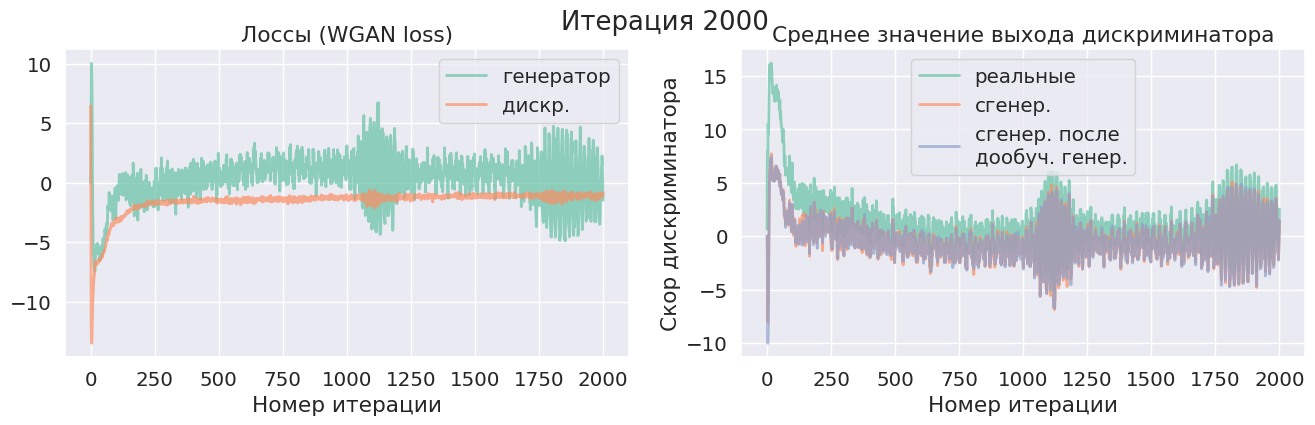

In [12]:
(
    img_list,
    losses_gen,
    losses_disc,
    D_real_means,
    D_fake_means,
    DG_fake_means,
) = train_gan(
    generator=generator,
    discriminator=discriminator,
    train_loader=train_loader,
    optim_generator=optim_generator,
    optim_discriminator=optim_discriminator,
    z_dim=z_dim,
    device=device,
    num_iter=num_iter,
    n_iter_generator=n_iter_generator,
    n_iter_discriminator=n_iter_discriminator,
    callback_frequency=callback_frequency,
    picture_save_frequency=picture_save_frequency,
    lambda_gp=lambda_gp,
    batch_size=batch_size,
    callback=callback,
)

Примеры генераций генератора:

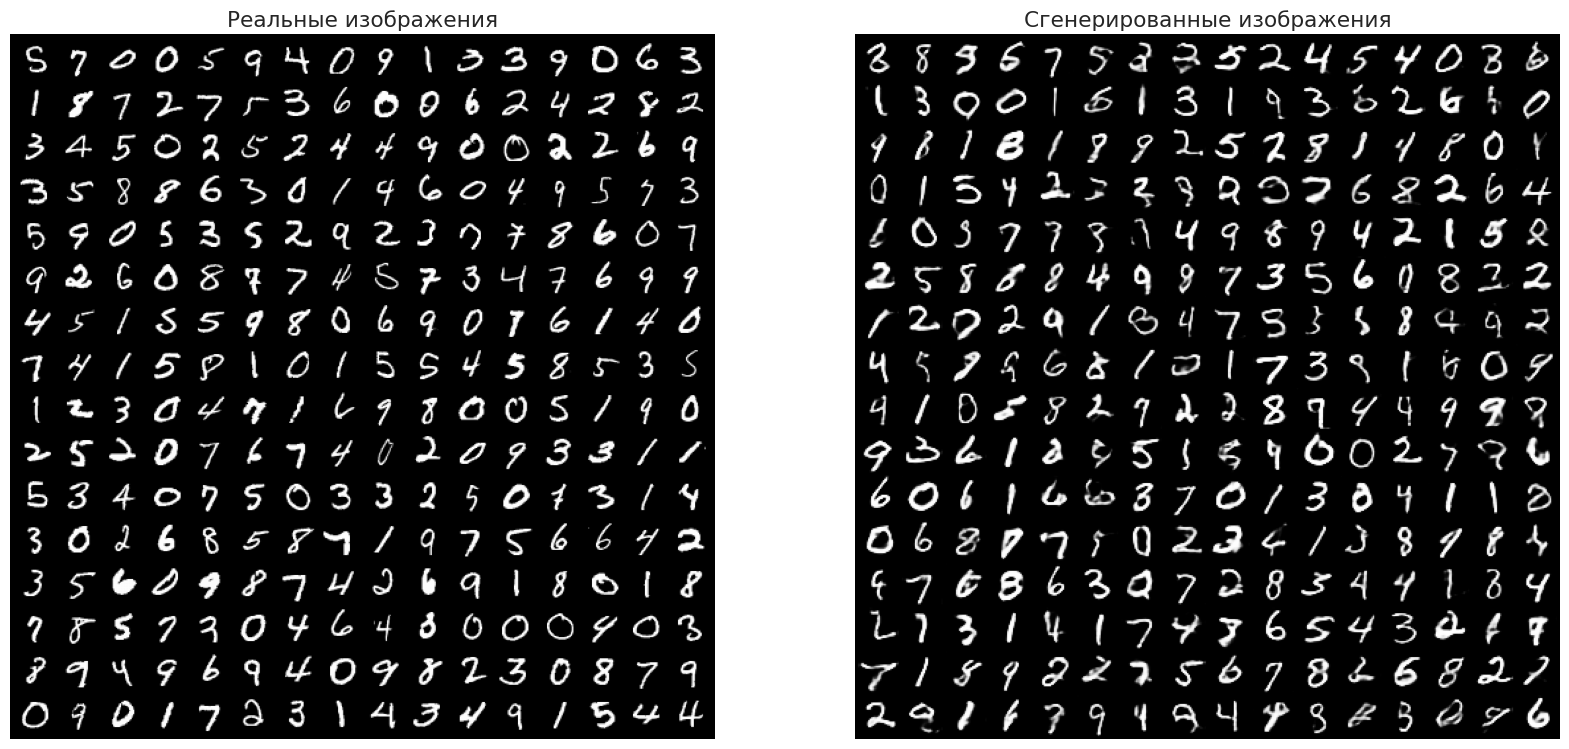

In [13]:
# Извлечем батч реальных изображений
real_batch = next(iter(train_loader))

# Рисуем реальные изображения
plt.figure(figsize=(20, 11))
plt.subplot(121)
plt.axis("off")
plt.title("Реальные изображения")
plt.imshow(np.transpose(vutils.make_grid(
    real_batch[0].to(device)[:256], nrow=16, padding=5, normalize=True
).cpu(), (1,2,0)))

# Рисуем сгенерированные изображения
plt.subplot(122)
plt.axis("off")
plt.title("Сгенерированные изображения")
plt.imshow(np.transpose(img_list[-1], (1,2,0)))
plt.show()

Получилось лучше, чем при использовании обычного WGAN

**3.** Оцените качество полученной модели. Для этого используйте метрику FID. Получилось ли ее улучшить по сравнению с моделью WGAN, представленной на семинаре?

In [14]:
fid_metric = FrechetInceptionDistance(feature=192).to(device)
torch.save({
    "generator": generator.state_dict(),
    "discriminator": discriminator.state_dict(),
}, "state.pt")
state_dict = torch.load("state.pt", map_location=device)
generator = Generator(z_dim, n_channel, p=0.1)
generator.load_state_dict(state_dict["generator"])
generator.to(device);

In [15]:
for batch, label in train_loader:
    # трансформируем тензор в стандартный вид для изображений
    batch = (batch * 255).to(torch.uint8).repeat_interleave(3, 1).to(device)
    # обновляем набор из реальных изображений
    fid_metric.update(batch, real=True)
    noise = torch.randn(batch_size, z_dim, device=device)
    with torch.no_grad():
        # трансформируем тензор в стандартный вид для изображений
        fake = (generator(noise) * 255).to(torch.uint8).repeat_interleave(3, 1)
    # обновляем набор из сгенерированных изображений
    fid_metric.update(fake, real=False)
# считаем метрику
fid_metrics = fid_metric.compute()

print(f"FID: {fid_metrics:.2f}")

FID: 0.11


**4.** Обучите две генеративные модели используя WGAN и WGAN-GP лоссы на искусственном датасете из прошлого ДЗ. Зафиксируйте архитектуры генератора и дискриминатора. Как для генератора, так
и для дискриминатора используйте 12-слойные полносвязные сети без BatchNorm с функцией активацией ReLU. Во время обучения используйте функции отрисовки графиков из прошлого ДЗ.

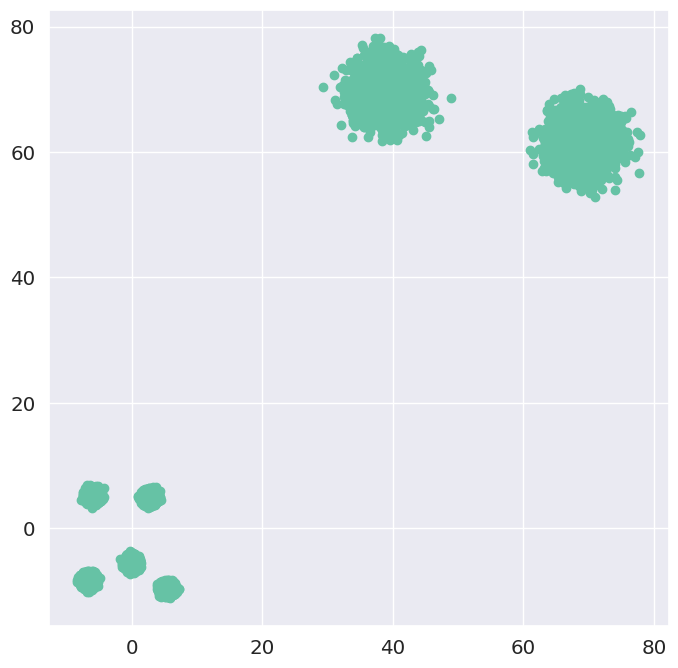

In [16]:
data1 = make_blobs(
    n_samples=10000, centers=5, cluster_std=0.5, random_state=10
)[0]
data2 = 30+5*make_blobs(
    n_samples=5000, centers=2, cluster_std=0.5, random_state=20
)[0]
data = np.vstack([data1, data2])

plt.figure(figsize=(8, 8))
plt.scatter(data[:, 0], data[:, 1]);

In [17]:
data = torch.tensor(data, dtype=torch.float32)

train_data, val_data = train_test_split(data, test_size=0.2)

train_dataset = TensorDataset(train_data)
val_dataset = TensorDataset(val_data)

train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=256, shuffle=False)


In [18]:
def make_grid(real_data, generated_data, step=0.5):
    '''
    Создание сетки, определяемой границами данных.
    '''
    xmin = min(generated_data[:, 0].min(), real_data[:, 0].min())
    xmax = max(generated_data[:, 0].max(), real_data[:, 0].max())
    ymin = min(generated_data[:, 1].min(), real_data[:, 1].min())
    ymax = max(generated_data[:, 1].max(), real_data[:, 1].max())

    xdelta = xmax - xmin
    ydelta = ymax - ymin
    xmin, xmax = xmin - 0.2 * xdelta, xmax + 0.2 * xdelta
    ymin, ymax = ymin - 0.2 * ydelta, ymax + 0.2 * ydelta

    X, Y = np.mgrid[xmin:xmax:step, ymin:ymax:step]
    return X, Y

def make_grid_predict(discriminator, X, Y):
    device = next(discriminator.parameters()).device
    XY2 = torch.tensor(np.vstack([X.ravel(), Y.ravel()]).T, device=device, dtype=torch.float32)
    with torch.no_grad():
        P = discriminator(XY2).cpu().numpy().reshape(X.shape)
    return P


def callback(
    real_data,
    generated_data,
    grid_X,
    grid_Y,
    grid_pred,
    losses_generator, 
    losses_discriminator, 
    D_real_means, 
    D_fake_means, 
    DG_fake_means, 
    it,
    file_name_prefix=None,
):
    '''
    Отрисовка текущего статуса обучения.
    real_data -- обучающие данные
    generated_data -- данные, сгенерированные генератором
    grid_X -- сетка значений X для визуализации
    grid_Y -- сетка значений Y для визуализации
    grid_pred -- сетка значений выходов дискриминатора для визуализации
    losses_generator -- значение лосса генератора по итерациям
    losses_discriminator -- значение лосса дискриминатора по итерациям
    D_real_means -- среднее значение дискриминатора на реальных объектах по итерациям
    D_fake_means -- среднее значение дискриминатора на сгенерированных объектах по итерациям
    DG_fake_means -- среднее значение дискриминатора на сгенерированных объектах 
                     по итерациям после обучения генератора
    it -- номер итерации
    file_name_prefix -- префикс имени файла для сохранения графика
    '''

    # Отложенная очистка экрана
    clear_output(wait=True)
    
    # Объявление фигуры и сетки
    fig = plt.figure(figsize=(16, 16), constrained_layout=False)
    gs = GridSpec(3, 2)
    fig.suptitle(f'Итерация {it}', fontsize=24)
    
    ax = fig.add_subplot(gs[0, 0])
    ax.plot(losses_generator, lw=2, label='генератор', alpha=0.7)
    ax.plot(losses_discriminator, lw=2, label='дискр.', alpha=0.7)
    ax.set_title('Лоссы')
    ax.legend()
    ax.set_xlabel('Номер итерации')
    
    ax = fig.add_subplot(gs[0, 1])
    ax.plot(D_real_means, lw=2, label='реальные', alpha=0.7)
    ax.plot(D_fake_means, lw=2, label='сгенер.', alpha=0.7)
    ax.plot(DG_fake_means, lw=2, label='сгенер. после\nдообуч. генер.', alpha=0.7)
    ax.set_title('Среднее значение выхода дискриминатора')
    ax.set_ylabel('Вер-ть real')
    ax.set_xlabel('Номер итерации')
    ax.legend()
    
    ax = fig.add_subplot(gs[1:, :])
    ax.pcolormesh(grid_X, grid_Y, grid_pred, cmap='Greens', shading='auto')
    ax.scatter(real_data[:, 0], real_data[:, 1], alpha=0.3, label='Данные')
    ax.scatter(generated_data[:, 0], generated_data[:, 1], alpha=0.3, label='Тек. генерация')
    ax.set_title('Выход декодера, темный цвет соответствует real')
    ax.legend()
    
    plt.tight_layout()
    
    # Сохранение в файл
    if file_name_prefix is not None:
        plt.savefig(f'{file_name_prefix}_{it}.png')
    
    plt.show()

In [19]:
class Generator(nn.Module):
    def __init__(self, z_dim=2, hidden_dim=64):
        super(Generator, self).__init__()
        
        self.layers = nn.ModuleList()
        in_features = z_dim
        
        for i in range(11):
            self.layers.append(nn.Linear(in_features, hidden_dim))
            self.layers.append(nn.ReLU(inplace=True))
            in_features = hidden_dim
        
        self.layers.append(nn.Linear(in_features, 2))

    def forward(self, x):
        for layer in self.layers:
            x = layer(x)
        return x


class Discriminator(nn.Module):
    def __init__(self, hidden_dim=64):
        super(Discriminator, self).__init__()
        
        self.layers = nn.ModuleList()
        in_features = 2
        
        for i in range(11):
            self.layers.append(nn.Linear(in_features, hidden_dim))
            self.layers.append(nn.ReLU(inplace=True))
            in_features = hidden_dim
        
        self.layers.append(nn.Linear(in_features, 1))

    def forward(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

In [20]:
def train_gan(
    generator,
    discriminator,
    train_loader,
    optim_generator,
    optim_discriminator,
    z_dim,
    device,
    num_iter=2001,
    n_iter_generator=1,
    n_iter_discriminator=7,
    callback_frequency=200,
    picture_save_frequency=100,
    lambda_gp=10.0,
    batch_size=64,
    callback=None,
    clip_value=0.01,
    step=0.2,
):
    """
    Основной цикл обучения GAN/WGAN-GP для 2D данных.
    Возвращает:
        img_list               – список тензоров (для совместимости с исходным вызовом)
        losses_generator       – список значений лосса генератора
        losses_discriminator   – список значений лосса дискриминатора
        D_real_means, D_fake_means, DG_fake_means – списки средних значений выхода дискриминатора
    """

    img_list = []  # для совместимости пусть просто пустые картинки
    losses_generator = []
    losses_discriminator = []
    D_real_means, D_fake_means, DG_fake_means = [], [], []

    # Собираем все реальные данные (нужно для построения сетки)
    all_real = []
    for real_batch in train_loader:
        all_real.append(real_batch[0])
    real_data_full = torch.cat(all_real, dim=0).cpu().numpy()

    # итератор по данным
    data_iter = iter(train_loader)

    for it in range(num_iter):
        # === обновление дискриминатора ===
        for _ in range(n_iter_discriminator):
            try:
                real_batch = next(data_iter)[0].to(device)
            except StopIteration:
                data_iter = iter(train_loader)
                real_batch = next(data_iter)[0].to(device)

            noise = torch.randn(real_batch.size(0), z_dim, device=device)
            fake_batch = generator(noise).detach()

            return_discr = train_discriminator(
                discriminator,
                optim_discriminator,
                real_batch,
                fake_batch,
                lambda_gp=lambda_gp,
                clip_value=clip_value
            )

        # === обновление генератора ===
        for _ in range(n_iter_generator):
            return_generator = train_generator(
                generator,
                discriminator,
                optim_generator,
                z_dim,
                batch_size
            )

        # сохраняем метрики
        loss_G = return_generator[0]
        loss_D = return_discr[0]
        losses_generator.append(loss_G)
        losses_discriminator.append(loss_D)
        D_real_means.append(return_discr[1])
        D_fake_means.append(return_discr[2])
        DG_fake_means.append(return_generator[1])

        # === визуализация ===
        if callback and (it % callback_frequency == 0):
            with torch.no_grad():
                # генерируем точки для визуализации
                noise_vis = torch.randn(2000, z_dim, device=device)
                generated_data = generator(noise_vis).cpu().numpy()

                # создаем сетку и получаем ответы дискриминатора на ней
                grid_X, grid_Y = make_grid(real_data_full, generated_data, step=step)
                grid_pred = make_grid_predict(discriminator, grid_X, grid_Y)

            callback(
                real_data=real_data_full,
                generated_data=generated_data,
                grid_X=grid_X,
                grid_Y=grid_Y,
                grid_pred=grid_pred,
                losses_generator=losses_generator,
                losses_discriminator=losses_discriminator,
                D_real_means=D_real_means,
                D_fake_means=D_fake_means,
                DG_fake_means=DG_fake_means,
                it=it,
            )

        # === "картинка" для совместимости с интерфейсом ===
        if (it % picture_save_frequency == 0) or (it == num_iter - 1):
            with torch.no_grad():
                noise_sample = torch.randn(batch_size, z_dim, device=device)
                fake_sample = generator(noise_sample).detach().cpu()
            img_list.append(fake_sample)  # просто храним как список батчей

    return (
        img_list,
        losses_generator,
        losses_discriminator,
        D_real_means,
        D_fake_means,
        DG_fake_means,
    )

In [21]:
def weights_init(m):
    if isinstance(m, nn.Linear):
        nn.init.kaiming_normal_(m.weight, nonlinearity="relu")
        if m.bias is not None:
            nn.init.constant_(m.bias, 0.01)

Начнем с WGAN, для этого нужно обнулить $\lambda$, а также добавить клиппинг весов в дискриминатор

In [22]:
z_dim = 5
num_iter = 2001  # Количество итераций обучения
n_iter_generator = 1  # Количество итераций обучения генератора в одной общей итерации
n_iter_discriminator = (
    7  # Количество итераций обучения дискриминатора в одной общей итерации
)
callback_frequency = num_iter // 10  # Частота обновления графика
picture_save_frequency = 100  # Частота сохранения визуализации текущей генерации
lambda_gp = 0.0
clip_value = 0.01

lr = 0.0005  # learning rate

# Создадим фиксированный батч латентных векторов для визуализации
fixed_noise = torch.randn(batch_size, z_dim, device=device)

# Метки реальных и сгенерированных объектов
real_label = 1.0
fake_label = -1.0

generator_wgan = Generator(z_dim).to(device)
discriminator_wgan = Discriminator().to(device)

generator_wgan.apply(weights_init)
discriminator_wgan.apply(weights_init)

# Оптимизаторы
optim_generator_wgan = torch.optim.RMSprop(generator_wgan.parameters(), lr=lr)
optim_discriminator_wgan = torch.optim.RMSprop(discriminator_wgan.parameters(), lr=lr)

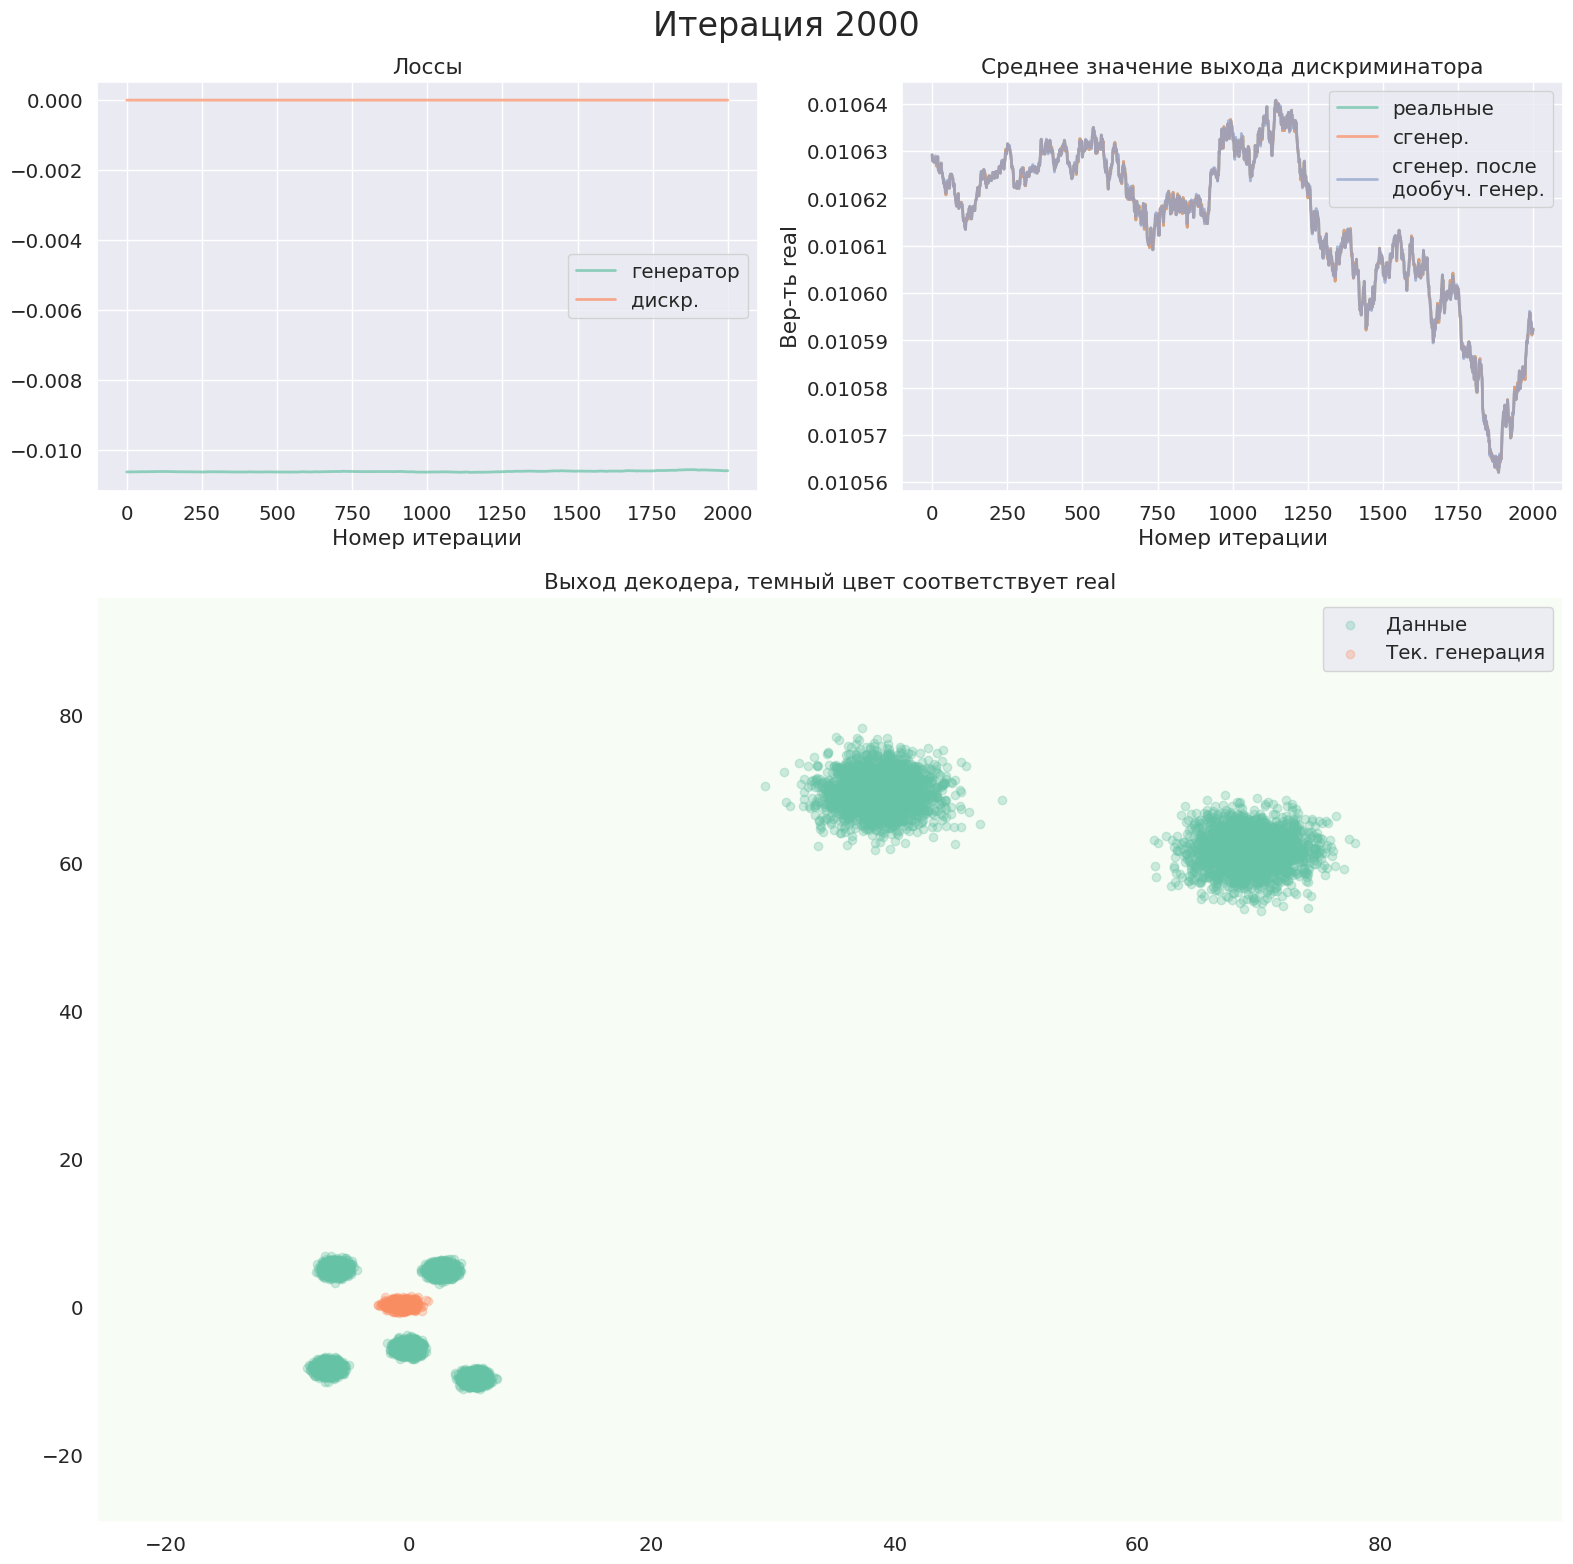

In [23]:
(
    img_list,
    losses_gen,
    losses_disc,
    D_real_means,
    D_fake_means,
    DG_fake_means,
) = train_gan(
    generator=generator_wgan,
    discriminator=discriminator_wgan,
    train_loader=train_loader,
    optim_generator=optim_generator_wgan,
    optim_discriminator=optim_discriminator_wgan,
    z_dim=z_dim,
    device=device,
    num_iter=num_iter,
    n_iter_generator=n_iter_generator,
    n_iter_discriminator=n_iter_discriminator,
    callback_frequency=callback_frequency,
    picture_save_frequency=picture_save_frequency,
    lambda_gp=lambda_gp,
    batch_size=batch_size,
    callback=callback,
    clip_value=clip_value,
)

Как видим, обучение застыло, что неудивительно, сеть слишком глубокая, так еще и в качестве активаций используется ReLU.

Клиппинг весов, как видим, не помогает.

Теперь обучим WGAN-GP, может на нем обучение запустится.

In [24]:
z_dim = 5
num_iter = 2001  # Количество итераций обучения
n_iter_generator = 1  # Количество итераций обучения генератора в одной общей итерации
n_iter_discriminator = (
    7  # Количество итераций обучения дискриминатора в одной общей итерации
)
callback_frequency = num_iter // 10  # Частота обновления графика
picture_save_frequency = 100  # Частота сохранения визуализации текущей генерации
lambda_gp = 10.0
clip_value = None

lr = 2e-4  # learning rate

# Создадим фиксированный батч латентных векторов для визуализации
fixed_noise = torch.randn(batch_size, z_dim, device=device)

# Метки реальных и сгенерированных объектов
real_label = 1.0
fake_label = -1.0

generator_wgan_gp = Generator(z_dim, hidden_dim=64).to(device)
discriminator_wgan_gp = Discriminator(hidden_dim=64).to(device)

generator_wgan_gp.apply(weights_init)
discriminator_wgan_gp.apply(weights_init)

# Оптимизаторы
optim_generator_wgan_gp = optim.Adam(generator_wgan_gp.parameters(), lr=lr, betas=(0.5, 0.999))
optim_discriminator_wgan_gp = optim.Adam(discriminator_wgan_gp.parameters(), lr=lr, betas=(0.5, 0.999))

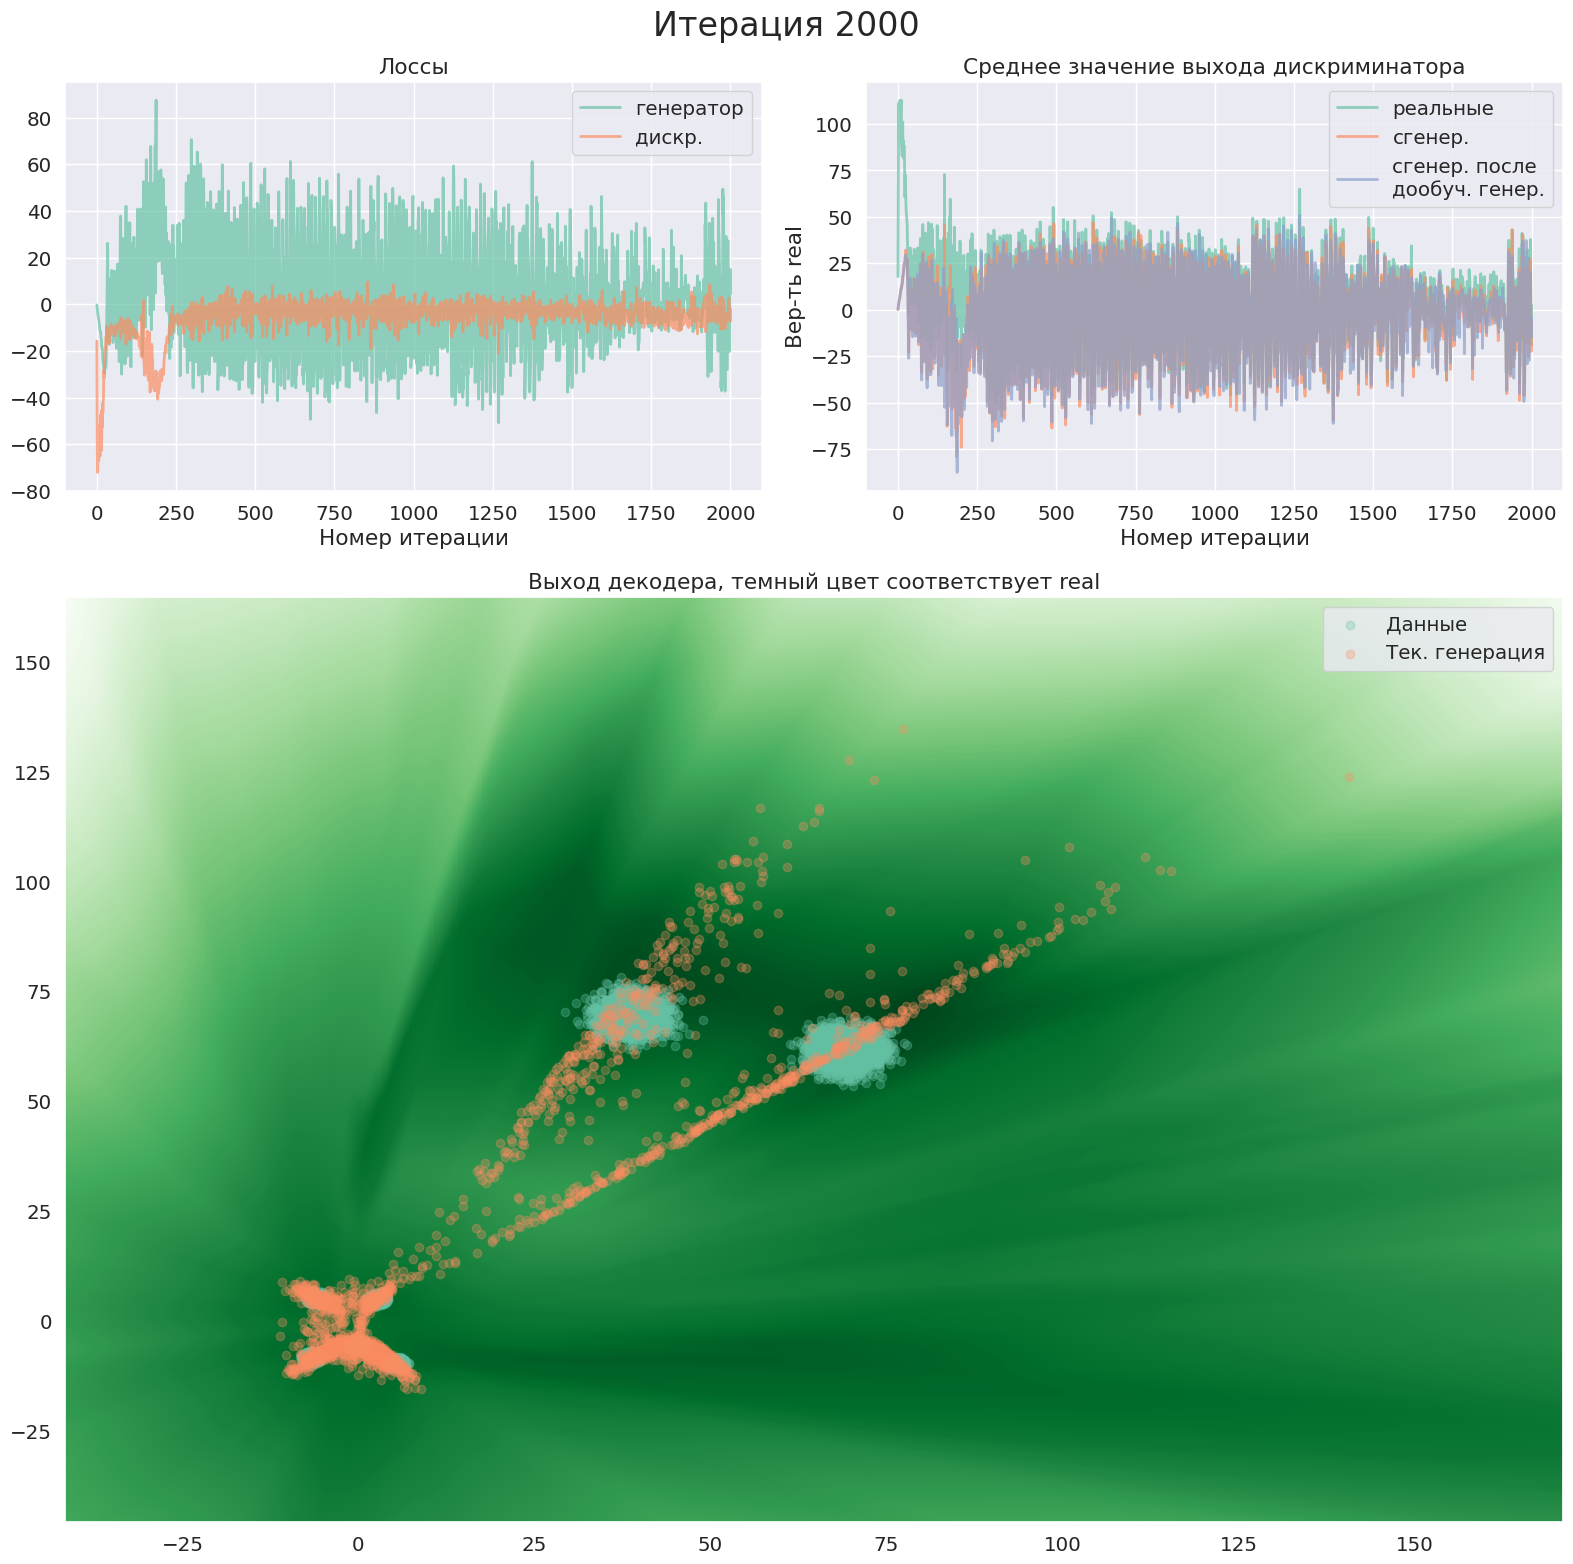

In [25]:
(
    img_list,
    losses_gen,
    losses_disc,
    D_real_means,
    D_fake_means,
    DG_fake_means,
) = train_gan(
    generator=generator_wgan_gp,
    discriminator=discriminator_wgan_gp,
    train_loader=train_loader,
    optim_generator=optim_generator_wgan_gp,
    optim_discriminator=optim_discriminator_wgan_gp,
    z_dim=z_dim,
    device=device,
    num_iter=num_iter,
    n_iter_generator=n_iter_generator,
    n_iter_discriminator=n_iter_discriminator,
    callback_frequency=callback_frequency,
    picture_save_frequency=picture_save_frequency,
    lambda_gp=lambda_gp,
    batch_size=batch_size,
    callback=callback,
    clip_value=clip_value,
)

Как видим, штраф на градиент работает намного лучше, чем клиппинг весов.

**5.** Визуализируйте распределения весов дискриминатора для каждой из полученных моделей. Какой вывод можно сделать?

In [26]:
def plot_weight_distributions(model, bins=50):
    weight_params = [(name, p.detach().cpu().flatten()) 
                     for name, p in model.named_parameters() if "weight" in name]
    
    num_layers = len(weight_params)
    n_cols = 5
    n_rows = math.ceil(num_layers / n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 4, n_rows * 3))
    axes = axes.flatten()

    for i, (name, weights) in enumerate(weight_params):
        ax = axes[i]
        ax.hist(weights.numpy(), bins=bins, color="steelblue", alpha=0.7)
        ax.set_title(name, fontsize=10)
        ax.set_xlabel("Weight value")
        ax.set_ylabel("Count")
    
    for j in range(i + 1, len(axes)):
        axes[j].axis("off")
    
    plt.tight_layout()
    plt.show()

Дискриминатор WGAN

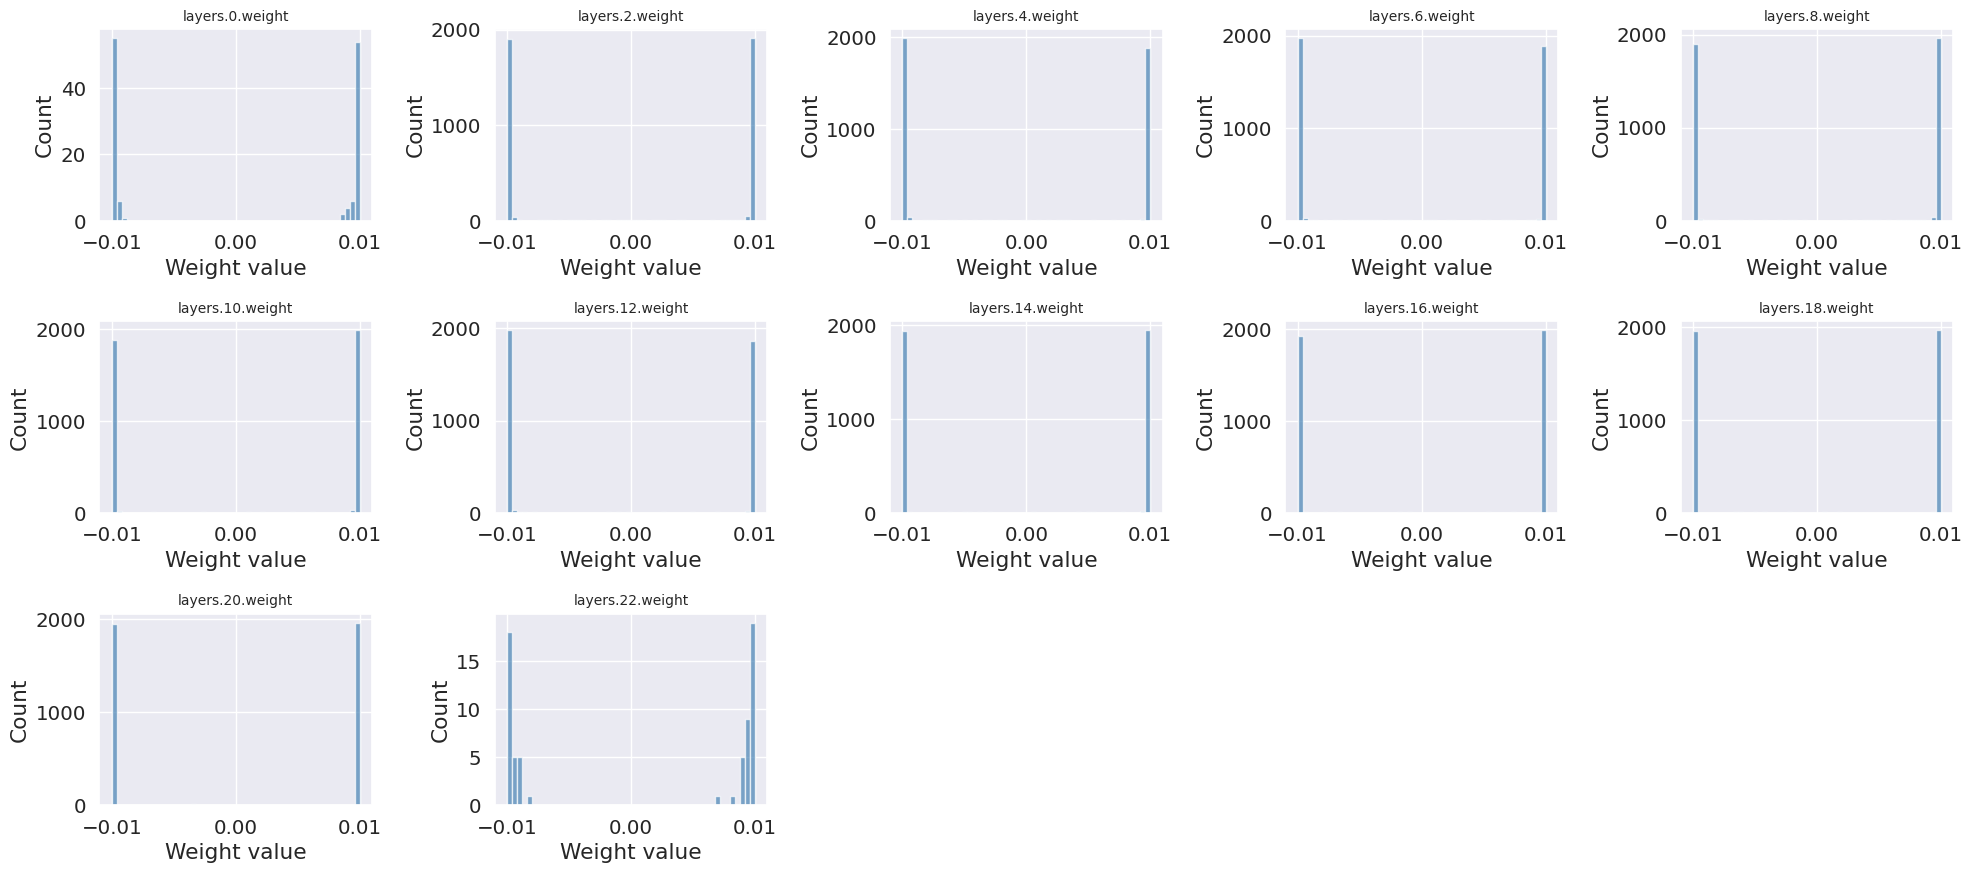

In [27]:
plot_weight_distributions(discriminator_wgan)

Ожидаемо -- сеть выродилась

Дискриминатор WGAN-GP

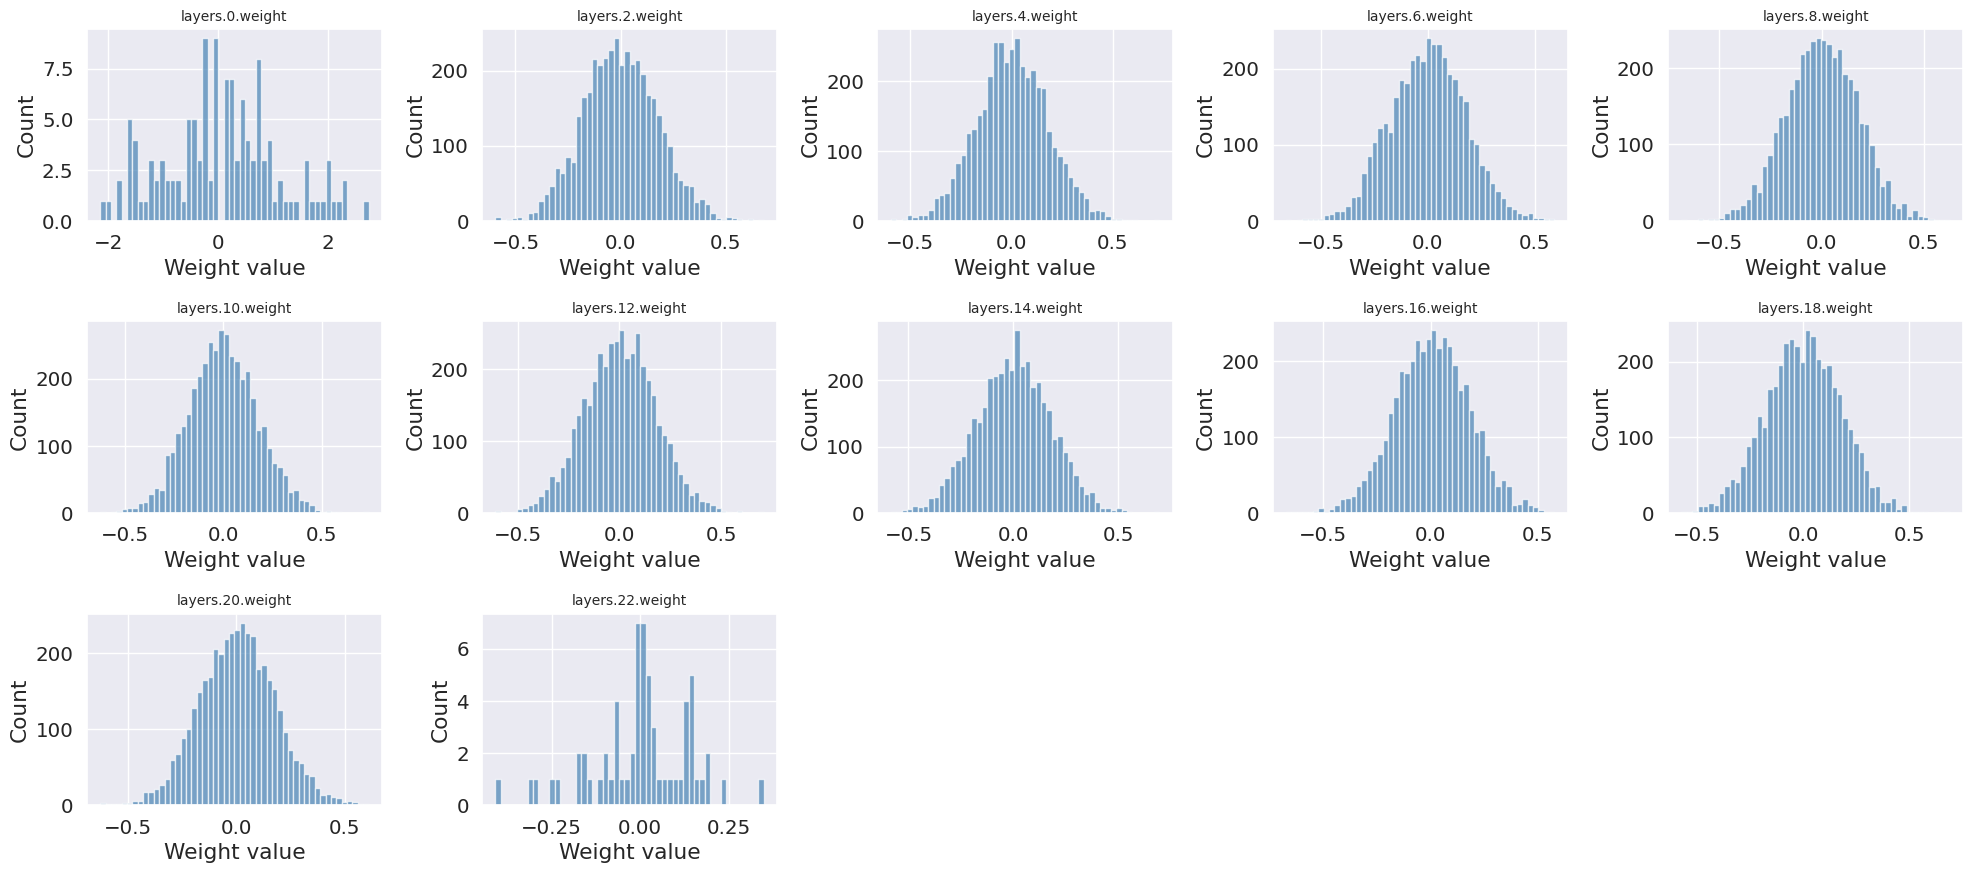

In [28]:
plot_weight_distributions(discriminator_wgan_gp)

А здесь все более менее адекватно.

**6.** Сделайте вывод об эффективности моделей WGAN и WGAN-GP. В качестве аргументов используйте свойства этих моделей, рассмотренные на занятии, а также особенности обучения, которые вы наблюдали на практике. Акцентируйте внимание на отличиях моделей.

**Выводы:**

Мы видим, что клиппинг весов оказался менее эффективным, чем штраф на норму градиента, что особенно выражено в глубоких сетях.

Также ипользовать WGAN не так выгодно, так как для него не подходит оптимизатор Adam, а нужно использовать RMSProp, что менее эффективно.

В целом, WGAN-GP выглядит хорошим развитием идеи WGAN, которая позволила обучать модели на глубоких сетях.